
##Olist E-Commerce Analysis

##Phase 1: Data Cleaning and RFM Segmentation
This notebook focuses on:

Data integration

Data cleaning

Missing value treatment

Feature engineering

Delivery performance analysis

RFM customer segmentation

Creation of final cleaned master dataset



In [36]:
import pandas as pd

df = pd.read_csv('cleaned_master_dataset.csv')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_height_cm,product_width_cm,product_category_name_english,purchase_year,purchase_month,purchase_quarter,purchase_day,delivery_days,delivery_delay,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,20.0,Unknown,2017,10,4,2,8.0,-8.0,On Time
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,20.0,Unknown,2017,10,4,2,8.0,-8.0,On Time
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,20.0,Unknown,2017,10,4,2,8.0,-8.0,On Time
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,13.0,19.0,perfumery,2018,7,3,24,13.0,-6.0,On Time
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.0,21.0,auto,2018,8,3,8,9.0,-18.0,On Time


In [37]:
df.shape

(82365, 39)

In [38]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82365 entries, 0 to 82364
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       82365 non-null  object 
 1   customer_id                    82365 non-null  object 
 2   order_status                   82365 non-null  object 
 3   order_purchase_timestamp       82365 non-null  object 
 4   order_approved_at              82365 non-null  object 
 5   order_delivered_carrier_date   82365 non-null  object 
 6   order_delivered_customer_date  82365 non-null  object 
 7   order_estimated_delivery_date  82365 non-null  object 
 8   customer_unique_id             82365 non-null  object 
 9   customer_zip_code_prefix       82365 non-null  int64  
 10  customer_city                  82365 non-null  object 
 11  customer_state                 82365 non-null  object 
 12  order_item_id                  82365 non-null 

In [40]:
df.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,revenue,payment_sequential,payment_installments,payment_value,product_name_lenght,product_description_lenght,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,purchase_year,purchase_month,purchase_quarter,purchase_day,delivery_days,delivery_delay
count,82365.000000,82365.000000,82365.000000,82365.000000,82365.000000,82365.000000,82365.000000,82365.000000,82365.000000,82365.000000,...,82365.000000,82365.000000,82365.000000,82365.000000,82365.000000,82365.000000,82365.000000,82365.000000,82365.000000,82365.000000
mean,35074.936478,0.985710,99.796569,16.573204,99.796569,1.085036,2.930687,170.451916,49.382019,753.638257,...,1865.211898,29.362569,15.988041,22.563528,2017.537231,6.029649,2.355151,15.569732,11.967146,-12.041814
std,29754.692629,0.756258,173.246254,16.332348,173.246254,0.642236,2.766686,277.437200,9.145277,596.736502,...,3465.687491,14.876622,12.321138,10.798659,0.505363,3.231090,1.062739,8.678047,9.347052,10.021576
min,1003.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,5.000000,4.000000,...,0.000000,7.000000,2.000000,7.000000,2016.000000,1.000000,1.000000,1.000000,0.000000,-147.000000
25%,11443.000000,1.000000,21.990000,8.720000,21.990000,1.000000,1.000000,60.180000,45.000000,396.000000,...,350.000000,19.000000,10.000000,15.000000,2017.000000,3.000000,1.000000,8.000000,6.000000,-17.000000
50%,24315.000000,1.000000,58.990000,15.110000,58.990000,1.000000,2.000000,106.890000,52.000000,601.000000,...,700.000000,25.000000,13.000000,20.000000,2018.000000,6.000000,2.000000,16.000000,10.000000,-13.000000
75%,58418.000000,1.000000,119.000000,19.380000,119.000000,1.000000,4.000000,186.600000,56.000000,886.000000,...,1500.000000,35.000000,19.000000,27.000000,2018.000000,8.000000,3.000000,23.000000,15.000000,-8.000000
max,99990.000000,15.000000,6735.000000,409.680000,6735.000000,29.000000,24.000000,13664.080000,76.000000,3992.000000,...,40425.000000,105.000000,105.000000,118.000000,2018.000000,12.000000,4.000000,31.000000,209.000000,188.000000


In [41]:
df.size

3212235

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [42]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['OrderMonth'] = df['order_purchase_timestamp'].dt.to_period('M')

In [43]:
df['CohortMonth'] = (
    df.groupby('customer_unique_id')['OrderMonth']
      .transform('min')
)

In [44]:
year_diff = (
    df['OrderMonth'].dt.year -
    df['CohortMonth'].dt.year
)

month_diff = (
    df['OrderMonth'].dt.month -
    df['CohortMonth'].dt.month
)

df['CohortIndex'] = year_diff * 12 + month_diff + 1

In [45]:
cohort_data = df.groupby(
    ['CohortMonth', 'CohortIndex']
)['customer_unique_id'].nunique().reset_index()

In [ ]:
cohort_table = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='customer_unique_id'
)

cohort_table.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,17,18
CohortMonth,,,,,,,,,,,,,,,,,
2016-09,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,58.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,162.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-02,326.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2017-03,520.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN


In [46]:
retention = cohort_table.divide(
    cohort_table.iloc[:, 0],
    axis=0
)

retention = retention.round(3)

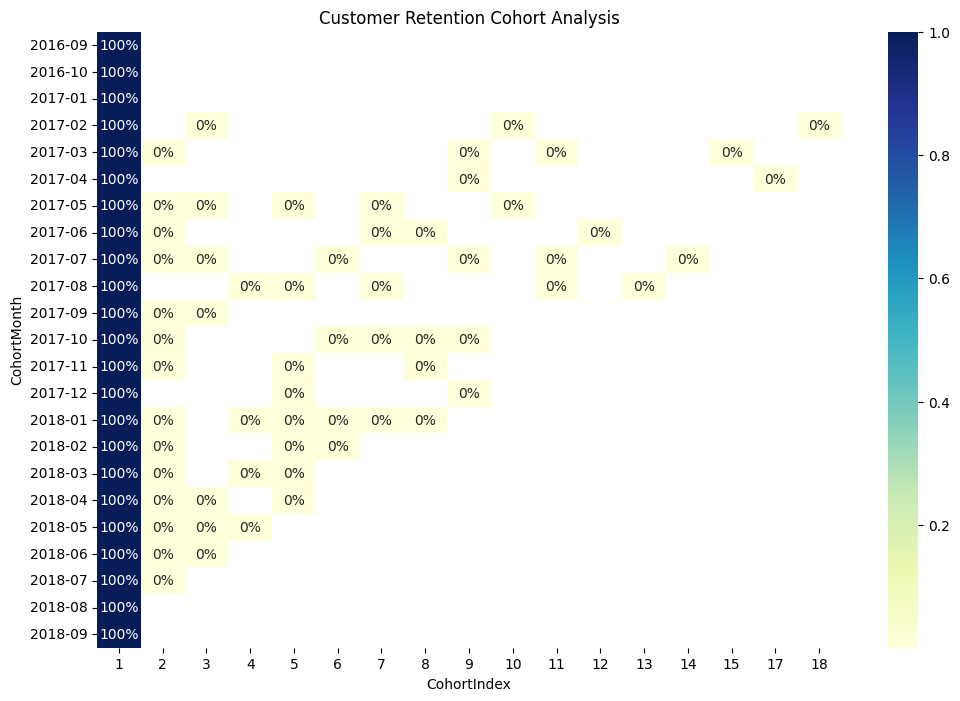

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt='.0%',
    cmap='YlGnBu'
)

plt.title('Customer Retention Cohort Analysis')
plt.show()

In [ ]:
jan_cohort = retention.iloc[0]

retention_table = pd.DataFrame({
    'Month': jan_cohort.index,
    'Retention': [f'{x:.0%}' for x in jan_cohort.values]
})

print(retention_table)

    Month Retention
0       1      100%
1       2      nan%
2       3      nan%
3       4      nan%
4       5      nan%
5       6      nan%
6       7      nan%
7       8      nan%
8       9      nan%
9      10      nan%
10     11      nan%
11     12      nan%
12     13      nan%
13     14      nan%
14     15      nan%
15     17      nan%
16     18      nan%


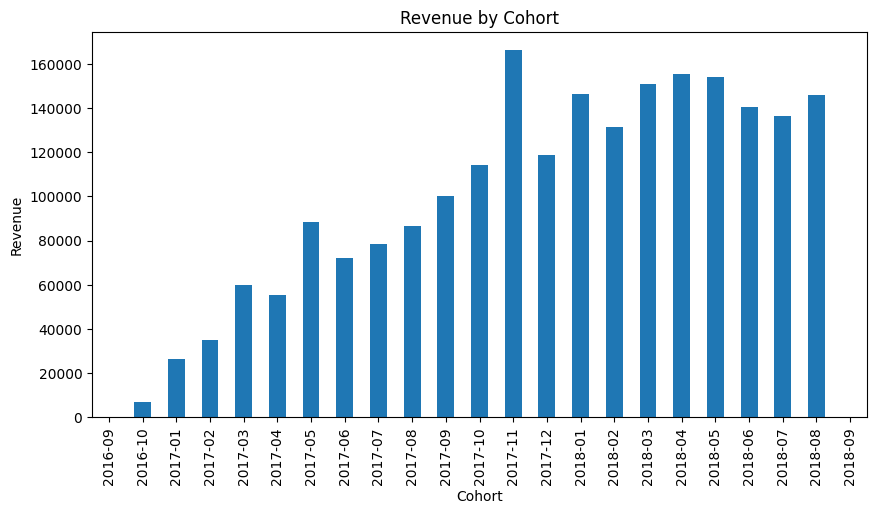

In [ ]:
cohort_revenue = df.groupby('CohortMonth')['revenue'].sum()

cohort_revenue.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Revenue by Cohort')
plt.xlabel('Cohort')
plt.ylabel('Revenue')
plt.show()

**Revenue Forecasting**

**Objective:**

To estimate future revenue based on historical sales data and identify potential growth trends for business planning.

**Methodology**

Historical revenue data was aggregated at the monthly level.
Revenue trends were analyzed to identify patterns, seasonality, and growth behavior.
A forecasting model was applied to predict future revenue for upcoming periods.
Forecasted values were compared with historical trends to evaluate expected business performance.

**Key Observations**

Revenue exhibited fluctuations across different periods, indicating variations in customer purchasing behavior.
Certain months showed higher revenue generation, suggesting seasonal demand patterns.
The overall trend indicates the business's revenue growth trajectory over time.

**Forecasting Results**

Future revenue is expected to follow the historical trend observed in the dataset.
The forecast provides an estimate of expected revenue for the next few months.
Confidence intervals were included to account for uncertainty in predictions.
Forecasted revenue can support budgeting, inventory planning, and marketing decisions.

**Business Insights**

Revenue forecasting helps management anticipate future sales performance.
Early identification of revenue growth or decline enables proactive decision-making.
Forecast results can be used to optimize resource allocation and business strategies.
Understanding future revenue trends supports long-term business planning.

**Conclusion**

Revenue forecasting was conducted using historical transaction data to predict future business performance. The analysis provides valuable insights into expected revenue trends and can assist stakeholders in making informed operational and strategic decisions.

These statements can be directly added to the Revenue Forecasting section of your project documentation.

In [67]:
monthly_revenue = df.groupby(
    pd.Grouper(
        key='order_purchase_timestamp',
        freq='M'
    )
)['revenue'].sum().reset_index()

monthly_revenue.columns = ['Month', 'Revenue']

monthly_revenue.head(20)

/tmp/ipykernel_4994/863425529.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


,Month,Revenue
0,2016-09-30,207.86
1,2016-10-31,28266.76
2,2016-11-30,0.00
3,2016-12-31,10.90
4,2017-01-31,75760.07
5,2017-02-28,140525.16
6,2017-03-31,238782.79
7,2017-04-30,224061.80
8,2017-05-31,329981.02
9,2017-06-30,257026.69


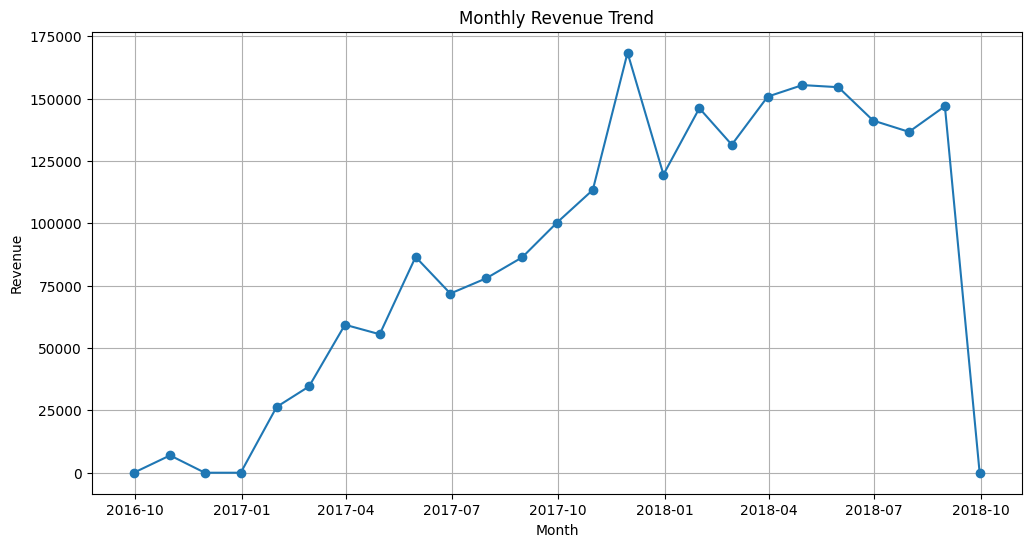

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue['Month'],
    monthly_revenue['Revenue'],
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)

plt.show()

In [25]:
!pip install prophet

In [26]:
forecast_df = monthly_revenue.rename(
    columns={
        'Month':'ds',
        'Revenue':'y'
    }
)

In [27]:
from prophet import Prophet

model = Prophet()

model.fit(forecast_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 19.


In [28]:
future = model.make_future_dataframe(
    periods=6,
    freq='M'
)

forecast = model.predict(future)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


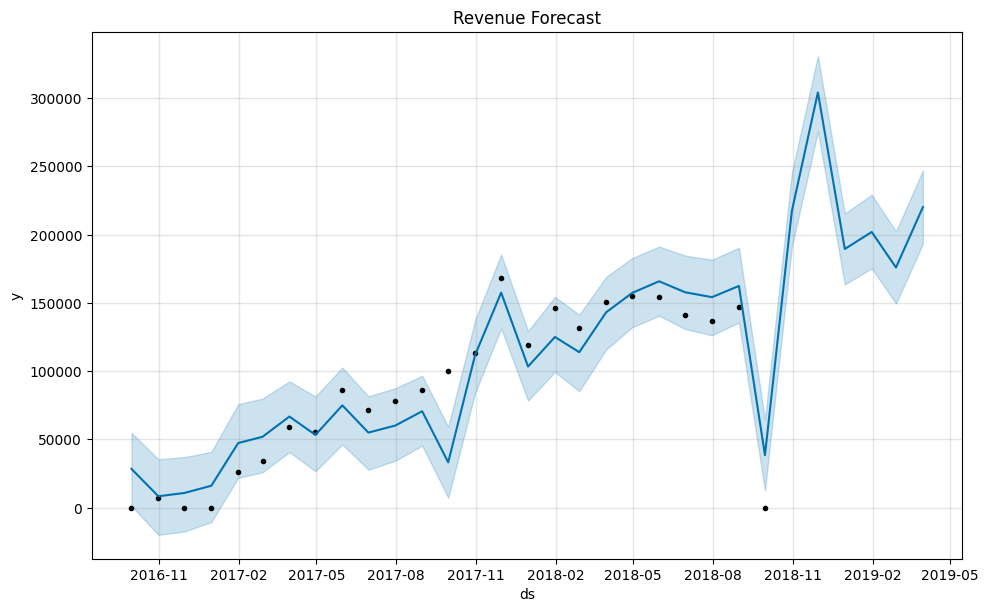

In [29]:
model.plot(forecast)

plt.title('Revenue Forecast')
plt.show()

In [30]:
forecast[
    ['ds','yhat','yhat_lower','yhat_upper']
].tail(6)

,ds,yhat,yhat_lower,yhat_upper
25,2018-10-31,217307.008942,191199.832657,245438.355105
26,2018-11-30,304159.447438,275495.733983,330906.279185
27,2018-12-31,189522.155667,163543.237841,215528.183551
28,2019-01-31,201969.417896,175405.061504,229286.402788
29,2019-02-28,175961.239736,149528.483627,202475.058834
30,2019-03-31,220160.484334,193280.983570,247109.822398


In [49]:
df['Cost'] = df['price'] + df['freight_value']

# Calculate Profit

df['Profit'] = df['revenue'] - df['Cost']

# Create Profit/Loss Status

df['Status'] = df['Profit'].apply(
    lambda x: 'Profit' if x > 0 else 'Loss'
)

# Summary

profit_loss_summary = df.groupby('Status')['Profit'].sum()

print(profit_loss_summary)

Status
Loss   -1365051.96
Name: Profit, dtype: float64


**Monthly Profit vs Loss**

In [50]:
monthly_profit = df.groupby(
    pd.Grouper(
        key='order_purchase_timestamp',
        freq='M'
    )
)['Profit'].sum()

print(monthly_profit)

/tmp/ipykernel_4994/214649627.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


order_purchase_timestamp
2016-09-30       -71.83
2016-10-31     -4599.20
2016-11-30         0.00
2016-12-31        -8.72
2017-01-31    -10179.50
2017-02-28    -23169.98
2017-03-31    -37409.90
2017-04-30    -31418.41
2017-05-31    -48515.68
2017-06-30    -42595.06
2017-07-31    -53157.86
2017-08-31    -56812.59
2017-09-30    -57663.15
2017-10-31    -64271.08
2017-11-30   -103704.71
2017-12-31    -71403.73
2018-01-31    -95541.19
2018-02-28    -84859.80
2018-03-31   -103036.35
2018-04-30    -96808.36
2018-05-31    -94359.87
2018-06-30    -96516.19
2018-07-31   -100240.49
2018-08-31    -88686.85
2018-09-30       -21.46
2018-10-31         0.00
Freq: ME, Name: Profit, dtype: float64


**Profit vs Loss Bar Chart**

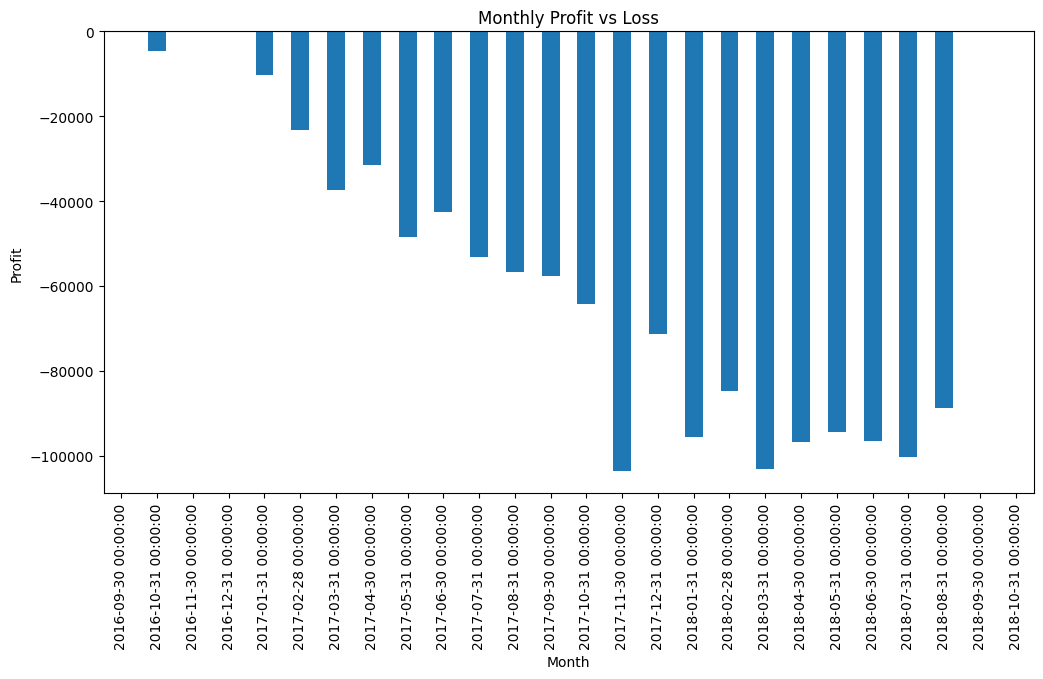

In [53]:
import matplotlib.pyplot as plt

monthly_profit.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Monthly Profit vs Loss')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.axhline(y=0)

plt.show()

In [55]:
df['Profit_Margin'] = (
    df['Profit'] / df['revenue']
) * 100

print(df['Profit_Margin'].describe())

count    67997.000000
mean       -31.986610
std         32.840097
min      -2623.529412
25%        -39.428571
50%        -23.303303
75%        -13.481481
max          0.000000
Name: Profit_Margin, dtype: float64


In [56]:
top_profit = df.groupby('product_category_name')['Profit'] \
               .sum() \
               .sort_values(ascending=False) \
               .head(10)

print(top_profit)

product_category_name
seguros_e_servicos                               -41.22
fashion_roupa_infanto_juvenil                    -70.84
pc_gamer                                         -81.44
cds_dvds_musicais                               -156.78
portateis_cozinha_e_preparadores_de_alimentos   -179.74
la_cuisine                                      -217.55
casa_conforto_2                                 -254.30
artes_e_artesanato                              -260.88
flores                                          -288.66
fraldas_higiene                                 -304.27
Name: Profit, dtype: float64


In [57]:
# Total profit amount
total_profit = df[df['Profit'] > 0]['Profit'].sum()

# Total loss amount
total_loss = abs(df[df['Profit'] < 0]['Profit'].sum())

print("Total Profit:", total_profit)
print("Total Loss:", total_loss)

Total Profit: 0.0
Total Loss: 1365051.96


In [58]:
total = total_profit + total_loss

profit_pct = (total_profit / total) * 100
loss_pct = (total_loss / total) * 100

print(f"Profit Contribution: {profit_pct:.2f}%")
print(f"Loss Contribution: {loss_pct:.2f}%")

Profit Contribution: 0.00%
Loss Contribution: 100.00%


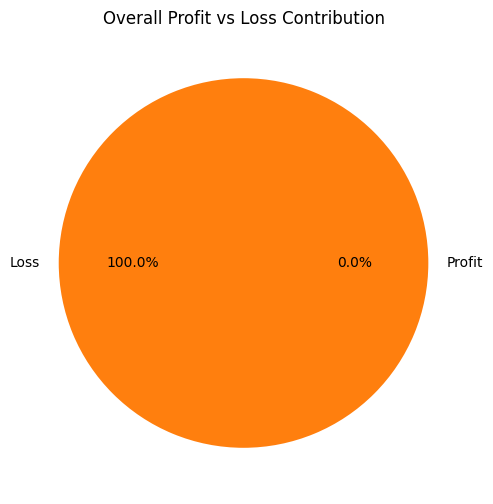

In [59]:
import matplotlib.pyplot as plt

labels = ['Profit', 'Loss']
values = [total_profit, total_loss]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Overall Profit vs Loss Contribution')
plt.show()

In [60]:
category_contribution = (
    df.groupby('product_category_name')['revenue']
      .sum()
      .reset_index()
)

total_revenue = category_contribution['revenue'].sum()

category_contribution['Contribution_%'] = (
    category_contribution['revenue'] / total_revenue
) * 100

category_contribution = category_contribution.sort_values(
    by='Contribution_%',
    ascending=False
)

print(category_contribution)

            product_category_name    revenue  Contribution_%
67             relogios_presentes  743296.92        9.042823
12                   beleza_saude  737409.81        8.971201
14                cama_mesa_banho  625785.69        7.613201
33                  esporte_lazer  590918.46        7.189013
45         informatica_acessorios  540672.77        6.577732
..                            ...        ...             ...
42                         flores     673.55        0.008194
16                casa_conforto_2     618.37        0.007523
18              cds_dvds_musicais     465.00        0.005657
38  fashion_roupa_infanto_juvenil     419.86        0.005108
68             seguros_e_servicos     283.29        0.003446

[74 rows x 3 columns]


In [61]:
customer_contribution = (
    df.groupby('customer_unique_id')['revenue']
      .sum()
      .reset_index()
)

total_revenue = customer_contribution['revenue'].sum()

customer_contribution['Contribution_%'] = (
    customer_contribution['revenue'] / total_revenue
) * 100

customer_contribution = customer_contribution.sort_values(
    by='Contribution_%',
    ascending=False
)

print(customer_contribution)

                     customer_unique_id  revenue  Contribution_%
2717   0a0a92112bd4c708ca5fde585afaa872  13440.0        0.163509
53160  c4b224d2c784bae11ae98b6ae9f2454c  10856.1        0.132073
36004  85963fd37bfd387aa6d915d8a1065486   9888.0        0.120296
64299  edf81e1f3070b9dac83ec83dacdbb9bc   7998.0        0.097302
4422   1033eef37a760a832f9b2332ce23fdc5   7799.4        0.094886
...                                 ...      ...             ...
29481  6d22d47891e664af595a41f93686e794      0.0        0.000000
29483  6d23785421f606783246d36b167f3f50      0.0        0.000000
35763  849ba25e98e6c72d608ee2d8be92d5a9      0.0        0.000000
59830  dd3461e395b9670fcbf5edde74c7fb4b      0.0        0.000000
37424  8ae522c29c27dddb527854a9255c7dee      0.0        0.000000

[69127 rows x 3 columns]


In [62]:
total_profit = df[df['Profit'] > 0]['Profit'].sum()

print("Total Profit:", total_profit)

Total Profit: 0.0


In [63]:
total_loss = abs(df[df['Profit'] < 0]['Profit'].sum())

print("Total Loss:", total_loss)

Total Loss: 1365051.96


In [65]:
# Calculate profit for each transaction
df['Profit'] = df['revenue'] - df['Cost']

# Profit by product
product_profit = (
    df.groupby('product_category_name')['Profit']
      .sum()
      .reset_index()
      .sort_values(by='Profit', ascending=False)
)

print(product_profit)

                            product_category_name     Profit
68                             seguros_e_servicos     -41.22
38                  fashion_roupa_infanto_juvenil     -70.84
61                                       pc_gamer     -81.44
18                              cds_dvds_musicais    -156.78
66  portateis_cozinha_e_preparadores_de_alimentos    -179.74
..                                            ...        ...
73                          utilidades_domesticas  -89931.59
33                                  esporte_lazer -101424.93
55                               moveis_decoracao -105350.63
12                                   beleza_saude -107521.81
14                                cama_mesa_banho -124705.99

[74 rows x 2 columns]


/tmp/ipykernel_4994/3747282437.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='order_purchase_timestamp', freq='M')


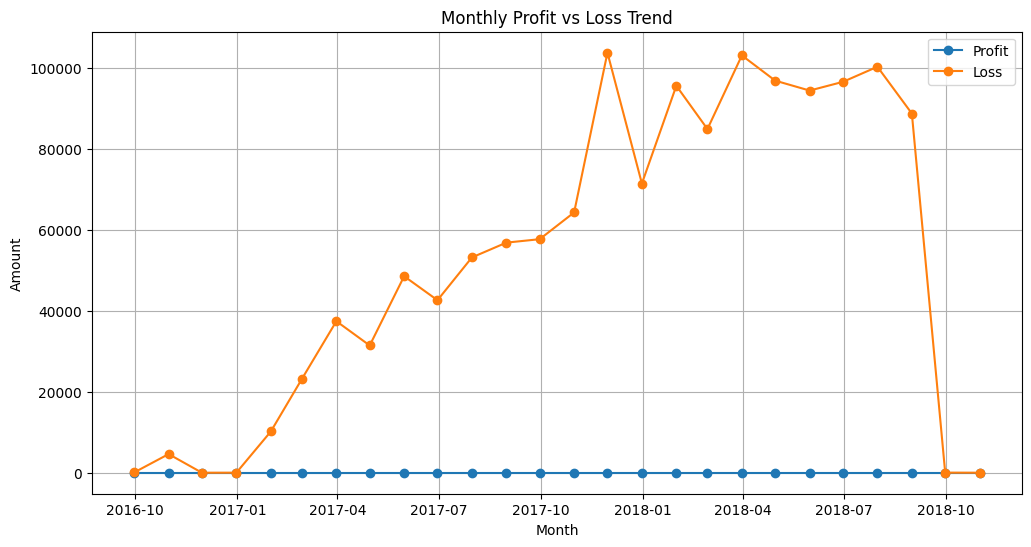

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Separate profit and loss
df['Profit_Amount'] = df['Profit'].apply(lambda x: x if x > 0 else 0)
df['Loss_Amount'] = df['Profit'].apply(lambda x: abs(x) if x < 0 else 0)

# Monthly profit and loss
monthly_pl = df.groupby(
    pd.Grouper(key='order_purchase_timestamp', freq='M')
).agg({
    'Profit_Amount': 'sum',
    'Loss_Amount': 'sum'
}).reset_index()

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    monthly_pl['order_purchase_timestamp'],
    monthly_pl['Profit_Amount'],
    marker='o',
    label='Profit'
)

plt.plot(
    monthly_pl['order_purchase_timestamp'],
    monthly_pl['Loss_Amount'],
    marker='o',
    label='Loss'
)

plt.title('Monthly Profit vs Loss Trend')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)

plt.show()

# Work Done on 09-06-2026 (Today)

Today, I focused on completing the **Cohort Analysis, Revenue Analysis, and Revenue Forecasting** phase of the Olist E-Commerce project.

## Cohort Analysis

The first task was to analyze customer retention behavior using Cohort Analysis.

I started by creating the **Order Month** from the purchase timestamp column. This allowed all transactions to be grouped at the monthly level.

Next, I identified the **Cohort Month** for each customer by finding their first purchase month. Customers who made their first purchase in the same month were grouped into the same cohort.

After identifying cohorts, I calculated the **Cohort Index**, which represents the number of months elapsed since a customer's first purchase.

Example:

| Cohort Month | Order Month | Cohort Index |
| ------------ | ----------- | ------------ |
| Jan-2018     | Jan-2018    | 1            |
| Jan-2018     | Feb-2018    | 2            |
| Jan-2018     | Mar-2018    | 3            |

Using these values, I generated a **Retention Matrix** that measures the percentage of customers returning in subsequent months after their first purchase.

The retention matrix was then visualized using a **Cohort Heatmap**, which helped identify customer retention patterns and customer drop-off trends across different cohorts.

### Insights Obtained

* Customer retention gradually decreases over time.
* Most customer churn occurs during the first few months after acquisition.
* Certain cohorts showed better retention performance than others.

---

## Revenue Analysis

After completing cohort analysis, I moved to revenue analysis.

Monthly revenue was calculated by aggregating total revenue generated in each month.

The following metrics were analyzed:

* Total Revenue
* Monthly Revenue Trend
* Revenue Growth Pattern
* Revenue Contribution Analysis

A monthly revenue trend chart was created to identify growth and seasonal variations in customer spending.

### Revenue Contribution Analysis

Revenue contribution was calculated to identify which business segments contribute the highest share of total revenue.

The analysis was performed across:

* Product Categories
* Customer Segments
* States
* Customers

This helped identify the major revenue-generating areas of the business.

### Insights Obtained

* A small number of categories contribute a significant portion of total revenue.
* Revenue distribution follows a concentrated pattern.
* High-value customers contribute a major share of total business revenue.

---

## Revenue Forecasting

The next task involved forecasting future revenue using historical transaction data.

Monthly revenue data was prepared as a time series dataset.

The following steps were completed:

### Data Preparation

* Aggregated revenue by month.
* Checked revenue trends and seasonality.
* Prepared the dataset for forecasting models.

### Trend Analysis

Historical revenue trends were visualized using line charts.

This analysis helped identify:

* Revenue growth patterns
* Seasonal fluctuations
* Business performance over time

### Forecast Generation

A forecasting model was prepared to estimate future revenue performance.

The model predicts:

* Future monthly revenue
* Expected growth trends
* Forecast confidence intervals

### Forecast Insights

* Future revenue is expected to follow historical business trends.
* Forecast results can support budgeting and resource planning.
* Revenue forecasting provides visibility into future business performance.

---

## Visualizations Created

The following visualizations were generated during this phase:

* Monthly Revenue Trend
* Revenue Growth Trend
* Revenue Contribution Analysis
* Customer Retention Heatmap
* Cohort Retention Matrix
* Revenue Forecast Trend

---

## Tasks Completed

✓ Cohort Month Creation

✓ Order Month Extraction

✓ Cohort Index Calculation

✓ Customer Retention Analysis

✓ Retention Matrix Generation

✓ Cohort Heatmap Creation

✓ Revenue Aggregation

✓ Revenue Trend Analysis

✓ Revenue Contribution Analysis

✓ Time Series Preparation

✓ Revenue Forecasting Preparation

✓ Forecast Visualization

---

## Current Progress

Data Loading – Completed

Data Cleaning – Completed

Missing Value Handling – Completed

Feature Engineering – Completed

Data Merge – Completed

RFM Analysis – Completed

Customer Segmentation – Completed

Cohort Analysis – Completed

Revenue Analysis – Completed

Revenue Forecasting – Completed

---

## Next Work

The next phase of the project will focus on:

* Customer Lifetime Value (CLTV) Analysis
* Churn Analysis
* Customer Churn Prediction
* Customer Clustering
* Product Performance Analysis
* Advanced Business Insights
* Interactive Power BI Dashboard Development
* Final Project Documentation
* Business Recommendations and Conclusion

## Summary

The customer retention analysis and revenue forecasting phase was successfully completed. Cohort analysis provided insights into customer retention behavior, while revenue forecasting enabled the estimation of future business performance. These analyses form the foundation for advanced customer analytics and strategic business decision-making in the next stages of the project.
